# Modelo base: SVR lineal y persistencia

Este notebook presenta las salidas guardadas del experimento ejecutado en `src/18_base_model.py`. Contiene el código completo: para repetir los 170 ajustes, establecer `REENTRENAR = True` y ejecutar desde el principio. Por defecto carga los resultados existentes, sin repetir entrenamiento. Requiere los datos y la estructura del repositorio, además de `requirements.txt`. TEST permanece reservado.

In [1]:
"""SVR lineal vs persistencia; selección y diagnóstico en DEVELOPMENT."""
from pathlib import Path
import json,hashlib,time,warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera,probplot,spearmanr
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVR
from sklearn.model_selection import TimeSeriesSplit
from sklearn.exceptions import ConvergenceWarning
import joblib,sklearn
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/splits/development_80.csv').is_file())
OUT=ROOT/'outputs/tables';FIG=ROOT/'book/_static/figures'
def metrics(y,p):
    return dict(rmse=float(np.sqrt(np.mean((y-p)**2))),mape=float(100*np.mean(abs((y-p)/y))) if np.all(y!=0) else np.nan,r2=float(1-np.sum((y-p)**2)/np.sum((y-y.mean())**2)),mae=float(np.mean(abs(y-p))))
def model(C,epsilon):
    return Pipeline([('scale',StandardScaler()),('svr',LinearSVR(C=C,epsilon=epsilon,loss='squared_epsilon_insensitive',dual=False,tol=1e-5,max_iter=20000,random_state=42))])
def fit(m,X,y):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always');m.fit(X,y)
    if any(issubclass(v.category,ConvergenceWarning) for v in w):raise RuntimeError('SVR no convergió')
    return m

def prepare(df,grid,L=168):
    frames={}
    for symbol,g in df.groupby('symbol'):
        assert not g.open_time.duplicated().any()
        g=g.set_index('open_time').reindex(grid)
        valid=g.close_time.eq(grid+pd.Timedelta(hours=1)-pd.Timedelta(milliseconds=1))
        c=g.close.where(valid&np.isfinite(g.close)&g.close.gt(0));r=np.log(c).diff()
        X=pd.DataFrame(np.column_stack([c.shift(k).to_numpy() for k in range(L)]),index=grid,columns=[f'lag_{k}' for k in range(L)])
        X['y']=100*r.rolling(24,min_periods=24).std(ddof=0).shift(-24)
        X['persistence']=100*r.rolling(24,min_periods=24).std(ddof=0)
        frames[symbol]=X
    common=np.logical_and.reduce([v.notna().all(axis=1).to_numpy() for v in frames.values()])
    return {s:v.loc[common] for s,v in frames.items()}

def main():
    started=time.perf_counter();source=ROOT/'data/splits/development_80.csv';sha=hashlib.sha256(source.read_bytes()).hexdigest()
    cfg=json.loads((OUT/'base_model_protocol.json').read_text())
    df=pd.read_csv(source,usecols=['symbol','open_time','close_time','close'])
    for col in ['open_time','close_time']:df[col]=pd.to_datetime(df[col],utc=True,format='ISO8601')
    grid=pd.date_range(df.open_time.min(),df.open_time.max(),freq='h')
    frames=prepare(df,grid,cfg['window_closes']);symbols=sorted(frames);cols=[f'lag_{k}' for k in range(cfg['window_closes'])]
    folds=list(TimeSeriesSplit(n_splits=5).split(grid));runs=[];preds={};audit=[]
    for C in cfg['C']:
      for eps in cfg['epsilon']:
        key=(C,eps);preds[key]=[]
        for f,(tr,va) in enumerate(folds,1):
          start,end=grid[va[0]],grid[va[-1]]
          for symbol in symbols:
            data=frames[symbol];train=data.loc[data.index+pd.Timedelta(hours=24)<start];val=data.loc[(data.index>=start)&(data.index<=end)]
            assert train.index.max()+pd.Timedelta(hours=24)<val.index.min()
            assert val.index.max()+pd.Timedelta(hours=24)<=grid.max()
            m=model(C,eps);tick=time.perf_counter();fit(m,train[cols],train.y);elapsed=time.perf_counter()-tick
            p=m.predict(val[cols]);assert np.isfinite(p).all()
            runs.append(dict(C=C,epsilon=eps,fold=f,symbol=symbol,n_train=len(train),n_val=len(val),fit_seconds=elapsed,n_iter=int(m.named_steps['svr'].n_iter_),**metrics(val.y.to_numpy(),p)))
            preds[key].append(pd.DataFrame({'time':val.index,'symbol':symbol,'fold':f,'y':val.y,'svr':p,'persistence':val.persistence}))
            if key==(cfg['C'][0],cfg['epsilon'][0]):audit.append(dict(fold=f,symbol=symbol,train_start=str(train.index.min()),train_end=str(train.index.max()),label_end=str(train.index.max()+pd.Timedelta(hours=24)),validation_start=str(val.index.min()),validation_end=str(val.index.max()),n_train=len(train),n_val=len(val)))
        print('Configuración completada',C,eps,flush=True)
    search=pd.DataFrame(runs);scores=search.groupby(['C','epsilon']).rmse.mean().sort_values();best=tuple(scores.index[0])
    search.to_csv(OUT/'base_search.csv',index=False);scores.rename('mean_rmse').reset_index().to_csv(OUT/'base_selection.csv',index=False)
    pd.DataFrame(audit).to_csv(OUT/'base_folds.csv',index=False)
    oof=pd.concat(preds[best],ignore_index=True);oof.to_csv(OUT/'base_validation_predictions.csv',index=False)
    rows=[];diagnostics=[];coeff=[];learn=[];cis=[]
    for symbol in symbols:
        part=oof.loc[oof.symbol.eq(symbol)].sort_values('time')
        for f,g in part.groupby('fold'):
            for name in ['svr','persistence']:rows.append(dict(symbol=symbol,fold=f,model=name,n=len(g),negative_predictions=int((g[name]<0).sum()),**metrics(g.y.to_numpy(),g[name].to_numpy())))
        # Curva con prefijos cronológicos del entrenamiento del último fold, validación fija.
        va=folds[-1][1];start,end=grid[va[0]],grid[va[-1]];data=frames[symbol]
        train=data.loc[data.index+pd.Timedelta(hours=24)<start];val=data.loc[(data.index>=start)&(data.index<=end)]
        for fraction in [.25,.5,1.]:
            sub=train.iloc[:max(2,int(len(train)*fraction))];m=fit(model(*best),sub[cols],sub.y)
            learn.append(dict(symbol=symbol,fraction=fraction,n_train=len(sub),train_rmse=metrics(sub.y.to_numpy(),m.predict(sub[cols]))['rmse'],validation_rmse=metrics(val.y.to_numpy(),m.predict(val[cols]))['rmse']))
        # Diagnóstico gráfico en el último fold; autocorrelación con rezagos de calendario.
        g=part.loc[part.fold.eq(5)].set_index('time');res=g.y-g.svr
        full=res.reindex(pd.date_range(g.index.min(),g.index.max(),freq='h'))
        correlations=[full.corr(full.shift(k)) for k in range(1,169)]
        jb=jarque_bera(res);rho=spearmanr(abs(res),g.svr).statistic
        diagnostics.append(dict(symbol=symbol,fold=5,mean_residual=res.mean(),std_residual=res.std(),jb_stat=jb.statistic,jb_p_iid=jb.pvalue,abs_residual_fitted_spearman=rho,variance_second_over_first=res.iloc[len(res)//2:].var()/res.iloc[:len(res)//2].var(),acf_1h=correlations[0],acf_24h=correlations[23],acf_168h=correlations[167]))
        fig,axes=plt.subplots(2,3,figsize=(15,8),constrained_layout=True)
        axes[0,0].plot(g.index,g.y,lw=.5,label='Real');axes[0,0].plot(g.index,g.svr,lw=.5,label='SVR');axes[0,0].plot(g.index,g.persistence,lw=.4,alpha=.6,label='Persistencia');axes[0,0].legend();axes[0,0].set_title('Validación fold 5 · volatilidad (%)')
        axes[0,1].plot(g.index,res,lw=.4);axes[0,1].set_title('Residuo = real − SVR')
        probplot(res,dist='norm',plot=axes[0,2]);axes[0,2].set_title('Q-Q normal · descriptivo')
        axes[1,0].scatter(g.svr,res,s=2,alpha=.15);axes[1,0].set_xlabel('Predicción');axes[1,0].set_ylabel('Residuo');axes[1,0].set_title('Dispersión y heterocedasticidad')
        axes[1,1].plot(range(1,169),correlations);axes[1,1].set_title('Autocorrelación residual · horas')
        lr=pd.DataFrame(learn).query('symbol == @symbol');axes[1,2].plot(lr.n_train,lr.train_rmse,marker='o',label='Entrenamiento');axes[1,2].plot(lr.n_train,lr.validation_rmse,marker='o',label='Validación fija');axes[1,2].legend();axes[1,2].set_title('Curva de aprendizaje cronológica · RMSE')
        for axis in axes[0,:2]:axis.tick_params(axis='x',rotation=45,labelsize=7)
        fig.suptitle(symbol+' · SVR lineal vs persistencia · DEVELOPMENT');fig.savefig(FIG/f'base_{symbol}.png',dpi=130);plt.close(fig)
        # Ajuste final DEVELOPMENT sin consultar TEST.
        final=fit(model(*best),data[cols],data.y)
        folder=ROOT/'outputs/models';folder.mkdir(exist_ok=True)
        joblib.dump(final,folder/f'linear_svr_{symbol}.joblib')
        b=final.named_steps['svr'].coef_;sc=final.named_steps['scale']
        coeff.extend(dict(symbol=symbol,lag_hours=k,standardized_coefficient=float(b[k]),coefficient_per_USDT=float(b[k]/sc.scale_[k])) for k in range(len(cols)))
    pd.DataFrame(rows).to_csv(OUT/'base_metrics_by_fold.csv',index=False)
    pd.DataFrame(rows).groupby('model')[['rmse','mape','r2','mae']].agg(['mean','std']).to_csv(OUT/'base_metrics_summary.csv')
    pd.DataFrame(diagnostics).to_csv(OUT/'base_residual_diagnostics.csv',index=False)
    pd.DataFrame(coeff).to_csv(OUT/'base_coefficients.csv',index=False);pd.DataFrame(learn).to_csv(OUT/'base_learning_curve.csv',index=False)
    # Bootstrap de bloques por fold, pareado entre modelos y activos; métrica macro RMSE.
    rng=np.random.default_rng(42);reps=cfg['bootstrap_reps'];rep_metrics=np.zeros((reps,2));point=np.zeros(2)
    for f,g in oof.groupby('fold'):
        idx=pd.date_range(g.time.min(),g.time.max(),freq='h');blocks=[]
        for name in ['svr','persistence']:
            sq=g.assign(error=(g.y-g[name])**2).pivot(index='time',columns='symbol',values='error').reindex(idx)
            arr=sq.to_numpy();mask=np.isfinite(arr);filled=np.nan_to_num(arr);B=168;n=len(arr)
            ext=np.concatenate([filled,filled[:B]]);em=np.concatenate([mask,mask[:B]])
            cs=np.vstack([np.zeros((1,5)),ext.cumsum(axis=0)]);cc=np.vstack([np.zeros((1,5)),em.cumsum(axis=0)])
            blocks.append((cs,cc,n,B));point[['svr','persistence'].index(name)]+=np.sqrt(np.nanmean(arr,axis=0)).mean()/5
        n=blocks[0][2];q,rem=divmod(n,168);starts=rng.integers(n,size=(reps,q));tail=rng.integers(n,size=reps)
        for j,(cs,cc,n,B) in enumerate(blocks):
            sums=(cs[starts+B]-cs[starts]).sum(axis=1);counts=(cc[starts+B]-cc[starts]).sum(axis=1)
            if rem:sums+=cs[tail+rem]-cs[tail];counts+=cc[tail+rem]-cc[tail]
            rep_metrics[:,j]+=np.sqrt(sums/counts).mean(axis=1)/5
    for j,name in enumerate(['svr','persistence']):cis.append(dict(metric='macro_rmse',model=name,estimate=point[j],low=np.quantile(rep_metrics[:,j],.025),high=np.quantile(rep_metrics[:,j],.975)))
    diff=rep_metrics[:,0]-rep_metrics[:,1];cis.append(dict(metric='delta_macro_rmse',model='svr_minus_persistence',estimate=point[0]-point[1],low=np.quantile(diff,.025),high=np.quantile(diff,.975)))
    pd.DataFrame(cis).to_csv(OUT/'base_confidence_intervals.csv',index=False)
    assert sha==hashlib.sha256(source.read_bytes()).hexdigest()
    meta={'selected_C':best[0],'selected_epsilon':best[1],'development_sha256':sha,'test_read':False,'eligible_common_per_asset':len(frames[symbols[0]]),'validation_rows_per_asset':len(oof)//5,'seconds':time.perf_counter()-started,'sklearn':sklearn.__version__,'selection_bias':'CI conditional on selected configuration; not independent final test','fits':150+15+5}
    (OUT/'base_metadata.json').write_text(json.dumps(meta,indent=2),encoding='utf-8')
    print(meta,flush=True);print(pd.DataFrame(cis).to_string(index=False),flush=True)
REENTRENAR = False
if REENTRENAR:
    main()
else:
    print('Se presentan los resultados guardados de los 170 ajustes. Cambiar REENTRENAR a True regenera el experimento completo sobre DEVELOPMENT.')


Se presentan los resultados guardados de los 170 ajustes. Cambiar REENTRENAR a True regenera el experimento completo sobre DEVELOPMENT.


# 3. Modelo base

## 3.1 Objetivo y alcance de la evaluación

El modelo base es **SVR lineal** y la referencia temporal es **persistencia**. El objetivo continuo es la volatilidad realizada futura de 24 retornos horarios, calculada como su desviación estándar centrada con divisor 24 (`ddof=0`). Se expresa en porcentaje y no se anualiza. No se utiliza regresión logística porque la tarea es de regresión, ni se confunden estos resultados con la regresión OLS diagnóstica de 2.5.

Para el ancla s, que identifica la apertura de la última vela observada, la predicción se realiza después de su cierre. Con retorno horario $r_{i,s}=\ln(C_{i,s}/C_{i,s-1})$:

$$
y_{i,s}=100\sqrt{\frac{1}{24}\sum_{j=1}^{24}(r_{i,s+j}-\bar r^+_{i,s})^2},\qquad
\bar r^+_{i,s}=\frac{1}{24}\sum_{j=1}^{24}r_{i,s+j}.
$$

Los resultados de esta sección proceden exclusivamente de validación cronológica en DEVELOPMENT. **TEST permanece reservado** hasta fijar los procedimientos de los modelos que se compararán al final. No se presenta esta validación como una evaluación final independiente. Las cifras antiguas de 2.1 no se reutilizan para construir el objetivo.

## 3.2 Entrada común y referencia de persistencia

Se fija antes del entrenamiento una ventana de **168 cierres horarios** (7 días de observaciones), con entradas desde `close(s)` hasta `close(s−167)`. El horizonte sigue siendo 24 horas y la ventana de volatilidad contiene 24 retornos; son tres parámetros distintos. Esta es la configuración de este experimento, no una conclusión de que 168 sea la mejor ventana. Los futuros modelos deberán usar esta misma información para compararse en este escenario.

`close` es la única variable explicativa original. Sus rezagos forman columnas diferentes y pueden presentar multicolinealidad. Se ajusta un modelo por activo; no se incorporan volumen, calendario o identificadores como entradas. Se exige una ventana completa de cierres válidos, un objetivo válido y disponibilidad de la referencia. Los cinco activos y ambos métodos se evalúan sobre timestamps comunes; no se filtran por errores obtenidos.

Persistencia utiliza la volatilidad reciente ya observable:

$$
\widehat y^{\mathrm{persistencia}}_{i,s}=100\,\operatorname{std}(r_{i,s-23},\ldots,r_{i,s};\mathrm{ddof}=0).
$$

Esos 24 retornos requieren 25 cierres que están contenidos en la ventana disponible al SVR. La referencia utiliza menos historia por su regla propia; no recibe información futura ni información de origen adicional. No necesita ajuste de parámetros. No es la media del entrenamiento utilizada como referencia en 2.5.

## 3.3 Partición y prevención de fuga

La partición DEVELOPMENT/TEST existente permanece intacta. Dentro de DEVELOPMENT se utiliza [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) con cinco folds de entrenamiento creciente. Se divide la rejilla horaria completa, no las filas apiladas de los activos: cada frontera es común a los cinco. Los huecos permanecen en el calendario y luego se aplica la elegibilidad de ventanas.

Una etiqueta de entrenamiento solo se admite si su última vela objetivo es anterior a la primera hora del bloque de validación. La comprobación se hace por fechas reales. Los horizontes que exceden DEVELOPMENT también quedan excluidos. Los históricos de validación pueden contener cierres anteriores al corte ya disponibles; no contienen observaciones posteriores al instante de predicción.

| Fold | Inicio entrenamiento | Última ancla entrenamiento | Inicio validación | Fin validación | n train | n val |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 2020-08-18 05:00 | 2021-06-03 20:00 | 2021-06-04 21:00 | 2022-03-29 10:00 | 5781 | 6561 |
| 2 | 2020-08-18 05:00 | 2022-03-28 10:00 | 2022-03-29 11:00 | 2023-01-21 00:00 | 12342 | 7142 |
| 3 | 2020-08-18 05:00 | 2023-01-20 00:00 | 2023-01-21 01:00 | 2023-11-14 14:00 | 19484 | 6949 |
| 4 | 2020-08-18 05:00 | 2023-11-13 14:00 | 2023-11-14 15:00 | 2024-09-07 04:00 | 26433 | 7142 |
| 5 | 2020-08-18 05:00 | 2024-09-06 04:00 | 2024-09-07 05:00 | 2025-06-30 18:00 | 33575 | 7118 |


Las fechas de la tabla son horas de apertura UTC de las velas ancla; el archivo de auditoría registra además la fecha final de las etiquetas de entrenamiento. Los tamaños son comunes a los activos por la intersección de elegibilidad. Esta regla puede reducir la cobertura y no garantiza que los periodos excluidos sean representativos de los incluidos.

## 3.4 Pipeline, formulación y búsqueda acotada

Se utiliza `Pipeline(StandardScaler, LinearSVR)`. Cada escalador se ajusta con su entrenamiento y se aplica sin reajuste a validación. [LinearSVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVR.html) implementa regresión de vectores de soporte lineal; se elige por su adecuación computacional a muchas observaciones. La configuración usa pérdida **epsilon-insensible al cuadrado**, `dual=False`, tolerancia $10^{-5}$, máximo 20.000 iteraciones y semilla 42. El intercepto de esta implementación está regularizado. No es OLS ni se afirma identidad numérica con `SVR(kernel="linear")` y su pérdida epsilon-insensible no cuadrática habitual.

La función predicha es lineal en los cierres estandarizados. Se penaliza la magnitud de los coeficientes y los errores que exceden el tubo de ancho epsilon. No se transforma ni escala la etiqueta. C controla la penalización del error frente a la regularización; epsilon está expresado en puntos porcentuales de volatilidad.

Antes de entrenar se fija la rejilla C ∈ {0,01; 0,1; 1} y epsilon ∈ {0,01; 0,1}: **seis configuraciones**, cinco folds y cinco activos, 150 ajustes de búsqueda. El criterio de selección es el RMSE medio con igual peso por activo y fold. Se selecciona una configuración común, sin elegir una diferente para cada activo. El presupuesto usa ejecución secuencial en CPU y un límite de iteraciones por ajuste; se guardan duración e iteraciones. No se amplía adaptativamente la rejilla según los resultados. Persistence queda exenta de búsqueda.

| C | epsilon (pp) | RMSE medio |
| --- | --- | --- |
| 0.01 | 0.01 | 0.618792 |
| 0.1 | 0.01 | 0.622726 |
| 1.0 | 0.01 | 0.623492 |
| 0.01 | 0.1 | 0.636124 |
| 0.1 | 0.1 | 0.640217 |
| 1.0 | 0.1 | 0.640901 |

Se seleccionan **C=0,01 y epsilon=0,01**. La ejecución completa tomó aproximadamente 207.8 segundos en el entorno local; no constituye una comparación de coste entre algoritmos.


La curva de aprendizaje añade 15 ajustes y el ajuste final sobre DEVELOPMENT añade cinco: 170 en total. Se guarda un pipeline final por activo, todavía sin evaluación en TEST. Las ventanas futuras, otros algoritmos y presupuestos deberán identificarse como experimentos propios bajo el protocolo común.

## 3.5 Comparación de desempeño

RMSE y MAE están en puntos porcentuales de volatilidad; MAPE se expresa en porcentaje y R² es adimensional. MAPE no se informa como finito si hay etiquetas iguales a cero; no se usan denominadores artificiales. Un R² negativo indica peor error cuadrático que la referencia constante de la media observada en ese bloque, no que el error sea negativo.

| Modelo | RMSE media ± DE | MAPE media ± DE (%) | R² media ± DE | MAE media ± DE |
| --- | --- | --- | --- | --- |
| persistence | 0.3881 ± 0.1082 | 40.4611 ± 6.7403 | -0.0424 ± 0.2371 | 0.2610 ± 0.0627 |
| svr | 0.6188 ± 0.3668 | 108.0650 ± 39.9438 | -1.8495 ± 2.6235 | 0.5322 ± 0.3271 |


La media y desviación se calculan sobre 25 combinaciones activo-fold con pesos iguales. La desviación entre bloques no es un intervalo de confianza. Los resultados por activo se resumen a continuación como media de sus cinco folds; el detalle completo conserva cada fold.

| Activo | Modelo | RMSE | MAPE (%) | R² |
| --- | --- | --- | --- | --- |
| BNBUSDT | persistence | 0.3332 | 39.05 | 0.0076 |
| BNBUSDT | svr | 0.5485 | 121.81 | -1.8886 |
| BTCUSDT | persistence | 0.2759 | 46.21 | -0.1396 |
| BTCUSDT | svr | 0.3569 | 97.10 | -0.9450 |
| ETHUSDT | persistence | 0.3404 | 40.83 | -0.1217 |
| ETHUSDT | svr | 0.5242 | 102.01 | -2.3083 |
| SOLUSDT | persistence | 0.4809 | 34.28 | 0.1213 |
| SOLUSDT | svr | 0.9336 | 103.57 | -2.8956 |
| XRPUSDT | persistence | 0.5099 | 41.93 | -0.0792 |
| XRPUSDT | svr | 0.7307 | 115.83 | -1.2101 |


Persistencia obtiene menor RMSE medio: **0,3881**, frente a **0,6188** del SVR. La diferencia es **0,2307 puntos porcentuales** a favor de persistencia. El SVR no supera la referencia en este experimento; los R² medios negativos y el MAPE elevado muestran sus limitaciones con cierres rezagados como entrada lineal. Se registraron **8 predicciones negativas** del SVR en las 174,560 predicciones de validación.

No se recortan predicciones negativas después de observar su desempeño. Se contabilizan y se reconocen como valores incompatibles con la no negatividad de la volatilidad. Cualquier restricción posterior deberá definirse como parte de un procedimiento distinto antes de evaluarlo.

## 3.6 Incertidumbre

Se utiliza bootstrap circular de bloques de **168 horas**, con 499 réplicas y semilla 42, separado dentro de cada fold. Se remuestrean conjuntamente los mismos bloques para los activos y los dos métodos, manteniendo los huecos del calendario. Se calcula en cada réplica el RMSE por activo y fold y luego su media con pesos iguales. La diferencia se define como RMSE del SVR menos RMSE de persistencia; un valor negativo favorece SVR.

| Métrica | Modelo o diferencia | Estimación | Límite 2,5 % | Límite 97,5 % |
| --- | --- | --- | --- | --- |
| macro_rmse | svr | 0.6188 | 0.5920 | 0.6427 |
| macro_rmse | persistence | 0.3881 | 0.3541 | 0.4173 |
| delta_macro_rmse | svr_minus_persistence | 0.2307 | 0.1994 | 0.2628 |


Los intervalos percentiles del 95 % son exploratorios y condicionados a las predicciones y a la configuración seleccionada. No incluyen la incertidumbre del proceso de selección ni un reajuste del modelo en cada réplica; los folds comparten entrenamiento y pueden reflejar regímenes distintos. La longitud de bloque fijada tampoco prueba independencia entre bloques. Por ello no se interpreta este intervalo como evidencia final independiente de superioridad. Esa conclusión requiere TEST reservado y los procedimientos fijados de antemano.

## 3.7 Residuos y dependencia temporal

Se define el residuo como observado menos predicho. Los paneles muestran el último fold: serie observada y predicha, residuos en el tiempo, gráfico Q-Q normal, dispersión frente a la predicción y autocorrelación residual hasta 168 horas. Los rezagos se calculan sobre el calendario, sin unir artificialmente extremos de huecos.

| Activo | Media residuo | ACF 1h | ACF 24h | ACF 168h | Correlación entre magnitud del residuo y predicción |
| --- | --- | --- | --- | --- | --- |
| BNBUSDT | -0.1812 | 0.9900 | 0.5410 | 0.2793 | 0.1818 |
| BTCUSDT | -0.2232 | 0.9889 | 0.5099 | 0.2989 | 0.2984 |
| ETHUSDT | -0.0375 | 0.9823 | 0.3918 | 0.2204 | 0.1029 |
| SOLUSDT | -0.1565 | 0.9886 | 0.5598 | 0.2570 | 0.2397 |
| XRPUSDT | -0.7272 | 0.9932 | 0.6425 | 0.3687 | 0.6667 |

Las medias residuales negativas indican sobreestimación media del SVR en el último fold. La autocorrelación a una hora supera 0,98 en los cinco activos y sigue siendo positiva a 24 y 168 horas. Las desviaciones del gráfico Q-Q y la variación de dispersión aconsejan evitar supuestos iid o gaussianos para cuantificar la incertidumbre.


La correlación de la magnitud del residuo con la predicción y el cociente entre varianzas de la segunda y primera mitad del bloque son diagnósticos descriptivos de dispersión variable; no son pruebas concluyentes de heterocedasticidad. El archivo de diagnóstico incluye Jarque–Bera, cuyos p-valores de referencia iid no se interpretan como inferencia calibrada bajo dependencia temporal. El gráfico Q-Q permite examinar desviaciones de normalidad sin confundir normalidad marginal con independencia.

La autocorrelación residual representa información temporal no capturada o dependencia inducida por las etiquetas solapadas. No demuestra por sí sola que esa información sea explotable por otro modelo. No corresponde aplicar Moran u otros diagnósticos espaciales porque no existen coordenadas.

## 3.8 Curvas de aprendizaje

Se ajusta la configuración seleccionada con el 25 %, 50 % y 100 % inicial del entrenamiento del último fold, manteniendo fija su validación y ajustando de nuevo el escalador en cada caso. Son prefijos cronológicos, no submuestras aleatorias. Se comparan los RMSE de entrenamiento y validación en los paneles.

| Activo | Fracción train | n train | RMSE train | RMSE validación |
| --- | --- | --- | --- | --- |
| BNBUSDT | 0.25 | 8393 | 0.7297 | 0.9929 |
| BNBUSDT | 0.5 | 16787 | 0.6161 | 0.4848 |
| BNBUSDT | 1.0 | 33575 | 0.5377 | 0.3443 |
| BTCUSDT | 0.25 | 8393 | 0.4055 | 0.8022 |
| BTCUSDT | 0.5 | 16787 | 0.3623 | 0.4821 |
| BTCUSDT | 1.0 | 33575 | 0.3405 | 0.3352 |
| ETHUSDT | 0.25 | 8393 | 0.5090 | 0.5845 |
| ETHUSDT | 0.5 | 16787 | 0.4653 | 0.4089 |
| ETHUSDT | 1.0 | 33575 | 0.4423 | 0.3373 |
| SOLUSDT | 0.25 | 8393 | 0.9330 | 0.9551 |
| SOLUSDT | 0.5 | 16787 | 0.8083 | 0.5199 |
| SOLUSDT | 1.0 | 33575 | 0.7466 | 0.4631 |
| XRPUSDT | 0.25 | 8393 | 0.9044 | 1.4231 |
| XRPUSDT | 0.5 | 16787 | 0.7630 | 0.9603 |
| XRPUSDT | 1.0 | 33575 | 0.6495 | 1.0422 |

El RMSE de validación disminuye al ampliar los prefijos en BNB, BTC, ETH y SOL. XRP mejora del 25 % al 50 %, pero empeora del 50 % al 100 %. No hay evidencia de que simplemente añadir más observaciones resuelva de forma uniforme las limitaciones del modelo.


La distancia entre ambos errores y su evolución orientan el diagnóstico de sobreajuste, insuficiencia de información o cambio de distribución. Al ampliar el prefijo también cambia el periodo representado y la cercanía al bloque validado; por tanto, la curva no aísla únicamente el efecto del tamaño muestral ni demuestra que la muestra sea suficiente. La configuración se eligió previamente con los cinco folds, así que esta curva es diagnóstica y no una evaluación adicional independiente.

## 3.9 Interpretación de coeficientes

Los coeficientes se guardan para los pipelines finales ajustados sobre DEVELOPMENT. Un coeficiente estandarizado expresa el cambio predicho en puntos porcentuales de volatilidad ante una desviación estándar de aumento en ese rezago, manteniendo los demás fijos. Se guarda también el coeficiente por unidad de USDT al dividirlo por la escala de su columna.

| Activo | Rezago (h) | Coeficiente estandarizado | Coeficiente por USDT |
| --- | --- | --- | --- |
| BNBUSDT | 0 | -0.320641 | -0.00172800 |
| BTCUSDT | 0 | -0.243138 | -0.00000947 |
| ETHUSDT | 0 | -0.386527 | -0.00040421 |
| SOLUSDT | 0 | -0.204474 | -0.00289488 |
| XRPUSDT | 0 | 0.059053 | 0.09141999 |


La tabla muestra el rezago con mayor coeficiente absoluto estandarizado por activo, no una selección de variables. Dada la fuerte correlación entre cierres consecutivos, los signos y magnitudes individuales pueden ser inestables y mantener otros rezagos fijos puede describir combinaciones poco habituales. No se interpretan como efectos causales ni como importancias robustas. La regularización ayuda a controlar coeficientes, pero no elimina la redundancia de la entrada.

## 3.10 Auditoría crítica y limitaciones

El máximo R² del SVR entre las 25 evaluaciones es 0.0258; no aparece un desempeño cercano a 0,8–0,9 que active esa alerta particular. Un resultado bajo tampoco demuestra ausencia de fuga. La inferioridad frente a persistencia muestra que el problema no queda resuelto por esta configuración lineal.

Se verificó que cambiar cierres futuros no altere la ventana de entrada de un ancla anterior, que los huecos invaliden las ventanas correspondientes y que los periodos objetivo de entrenamiento no invadan validación. Los ajustes no presentaron advertencias de falta de convergencia; las predicciones son finitas y se comparan sobre las mismas filas. Estas comprobaciones no constituyen una prueba universal de ausencia de fuga.

El EDA previo utilizó DEVELOPMENT y pudo orientar decisiones metodológicas. La selección y las métricas de esta sección usan los mismos cinco folds, por lo que pueden ser optimistas. La evidencia se limita a cinco activos, un proveedor y los periodos observados. Los movimientos extremos, los huecos y los cambios de distribución pueden afectar el desempeño futuro. No se afirma que otro modelo será mejor ni se cambia de dataset a partir de un resultado aislado.

## 3.11 Reproducibilidad y entregables

El protocolo se registra en `outputs/tables/base_model_protocol.json` antes del entrenamiento. El procedimiento está en `src/18_base_model.py`; las tablas, predicciones de validación, coeficientes y metadatos están en `outputs/tables/base_*.csv` y `base_metadata.json`. Los cinco pipelines finales se guardan en `outputs/models/linear_svr_*.joblib`. Se conserva el SHA-256 de DEVELOPMENT y no se lee TEST.

[Dependencias fijadas](../requirements.txt). El notebook registra la ejecución y los resultados del procedimiento. La entrega requiere el enlace publicado del Jupyter Book y el archivo `.ipynb`; localhost es una vista local, no un enlace accesible al profesor desde otro equipo. La evaluación final en TEST queda separada y no se presenta como realizada.

[Notebook del modelo base con resultados guardados](../../notebooks/18_base_model.ipynb).

base_selection.csv


,C,epsilon,mean_rmse
0,0.01,0.01,0.618792
1,0.10,0.01,0.622726
2,1.00,0.01,0.623492
3,0.01,0.10,0.636124
4,0.10,0.10,0.640217
5,1.00,0.10,0.640901


base_metrics_by_fold.csv


,symbol,fold,model,n,negative_predictions,rmse,mape,r2,mae
0,BNBUSDT,1,svr,6561,0,0.939420,139.816929,-4.613032,0.869395
1,BNBUSDT,1,persistence,6561,0,0.418178,33.464469,-0.112244,0.272938
2,BNBUSDT,2,svr,7142,0,0.546481,110.740734,-0.574264,0.463961
3,BNBUSDT,2,persistence,7142,0,0.367853,38.211836,0.286694,0.239209
4,BNBUSDT,3,svr,6949,0,0.525301,191.479478,-3.468027,0.489117
5,BNBUSDT,3,persistence,6949,0,0.279912,46.555772,-0.268653,0.184822
6,BNBUSDT,4,svr,7142,0,0.386861,80.558004,-0.350485,0.324863
7,BNBUSDT,4,persistence,7142,0,0.329174,39.529105,0.022244,0.216920
8,BNBUSDT,5,svr,7118,0,0.344327,86.477107,-0.437412,0.289447
9,BNBUSDT,5,persistence,7118,0,0.270985,37.472840,0.109712,0.182616


base_confidence_intervals.csv


,metric,model,estimate,low,high
0,macro_rmse,svr,0.618792,0.591950,0.642730
1,macro_rmse,persistence,0.388072,0.354086,0.417339
2,delta_macro_rmse,svr_minus_persistence,0.230720,0.199361,0.262815


base_residual_diagnostics.csv


,symbol,fold,mean_residual,std_residual,jb_stat,jb_p_iid,abs_residual_fitted_spearman,variance_second_over_first,acf_1h,acf_24h,acf_168h
0,BNBUSDT,5,-0.181241,0.292788,15654.948136,0.0,0.181772,0.928745,0.989995,0.540989,0.279285
1,BTCUSDT,5,-0.223190,0.250166,6936.983273,0.0,0.298405,1.005366,0.988873,0.509907,0.298910
2,ETHUSDT,5,-0.037464,0.335253,15563.643487,0.0,0.102877,1.729964,0.982256,0.391841,0.220421
3,SOLUSDT,5,-0.156513,0.435900,35440.048670,0.0,0.239718,0.859379,0.988572,0.559761,0.256975
4,XRPUSDT,5,-0.727188,0.746607,3478.930495,0.0,0.666691,0.700765,0.993217,0.642501,0.368708


base_learning_curve.csv


,symbol,fraction,n_train,train_rmse,validation_rmse
0,BNBUSDT,0.25,8393,0.729716,0.992900
1,BNBUSDT,0.50,16787,0.616079,0.484796
2,BNBUSDT,1.00,33575,0.537661,0.344327
3,BTCUSDT,0.25,8393,0.405538,0.802209
4,BTCUSDT,0.50,16787,0.362265,0.482052
5,BTCUSDT,1.00,33575,0.340513,0.335243
6,ETHUSDT,0.25,8393,0.509041,0.584527
7,ETHUSDT,0.50,16787,0.465331,0.408913
8,ETHUSDT,1.00,33575,0.442345,0.337317
9,SOLUSDT,0.25,8393,0.932952,0.955124


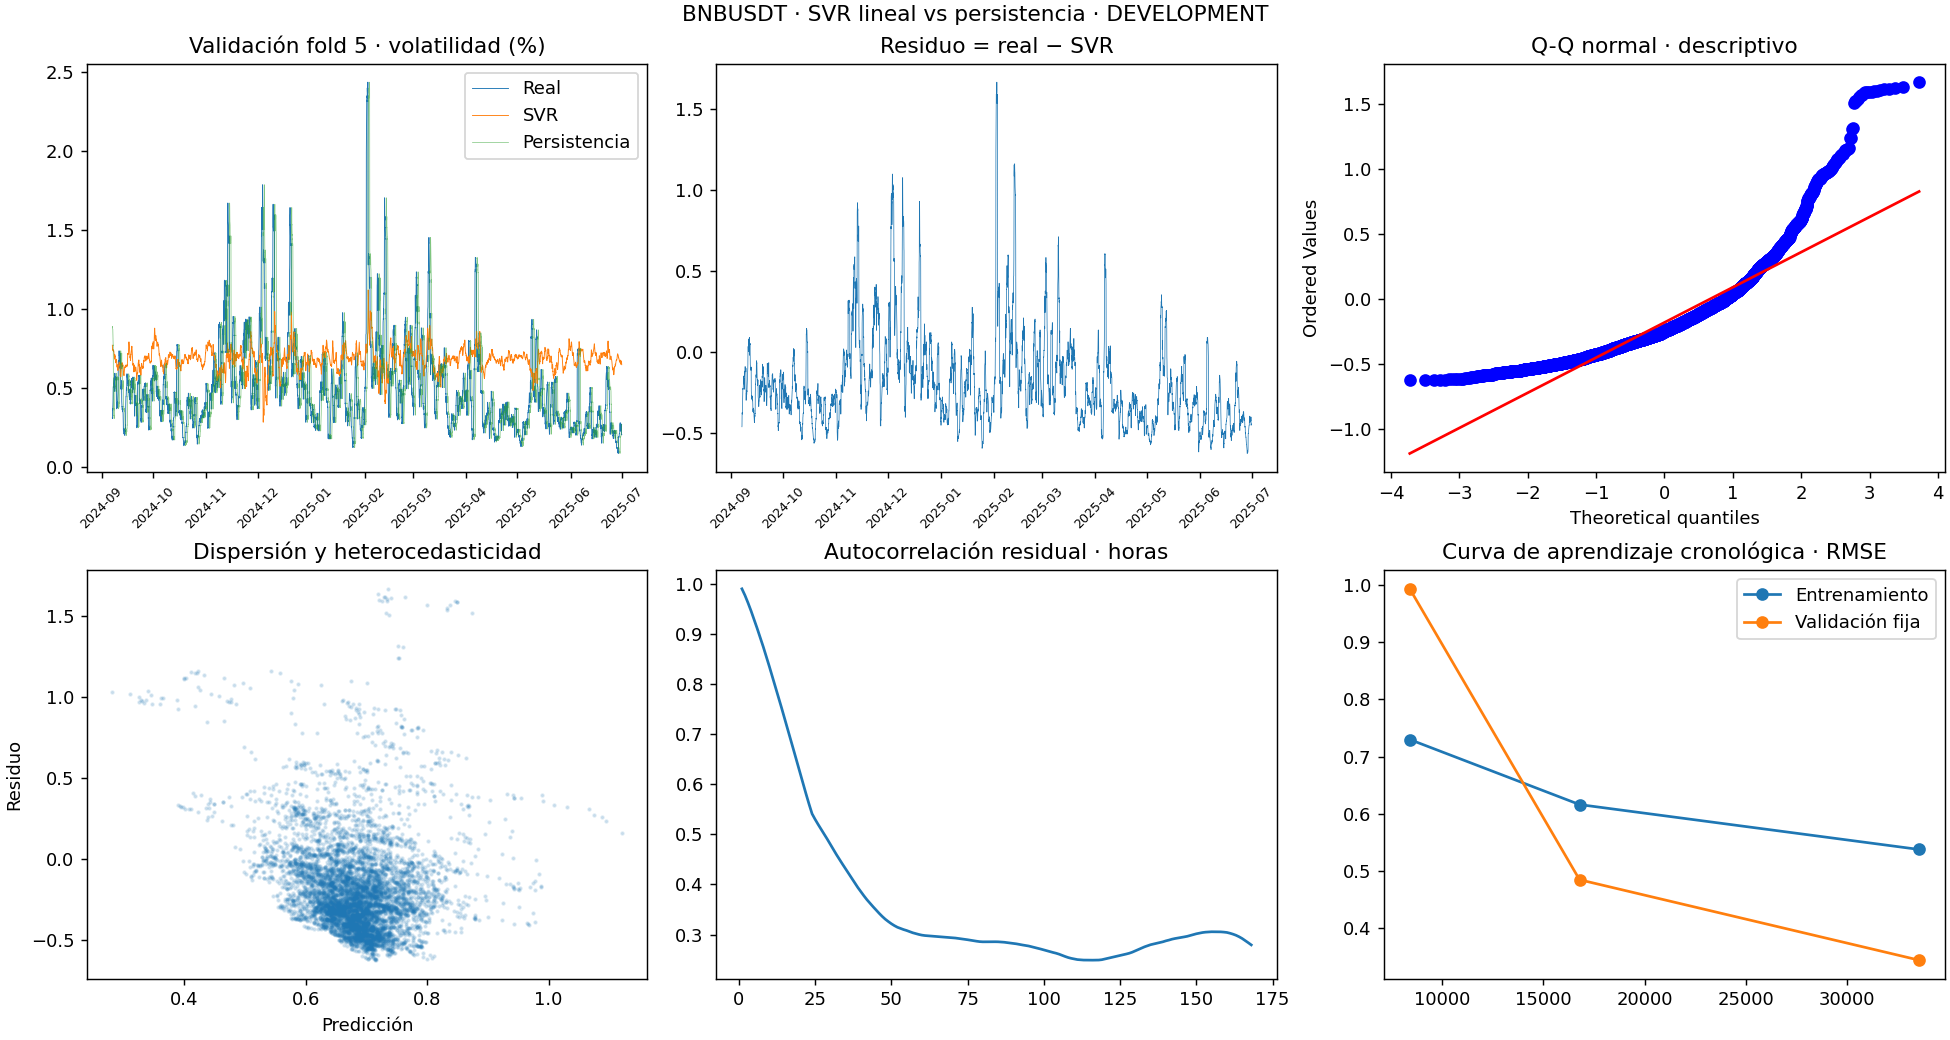

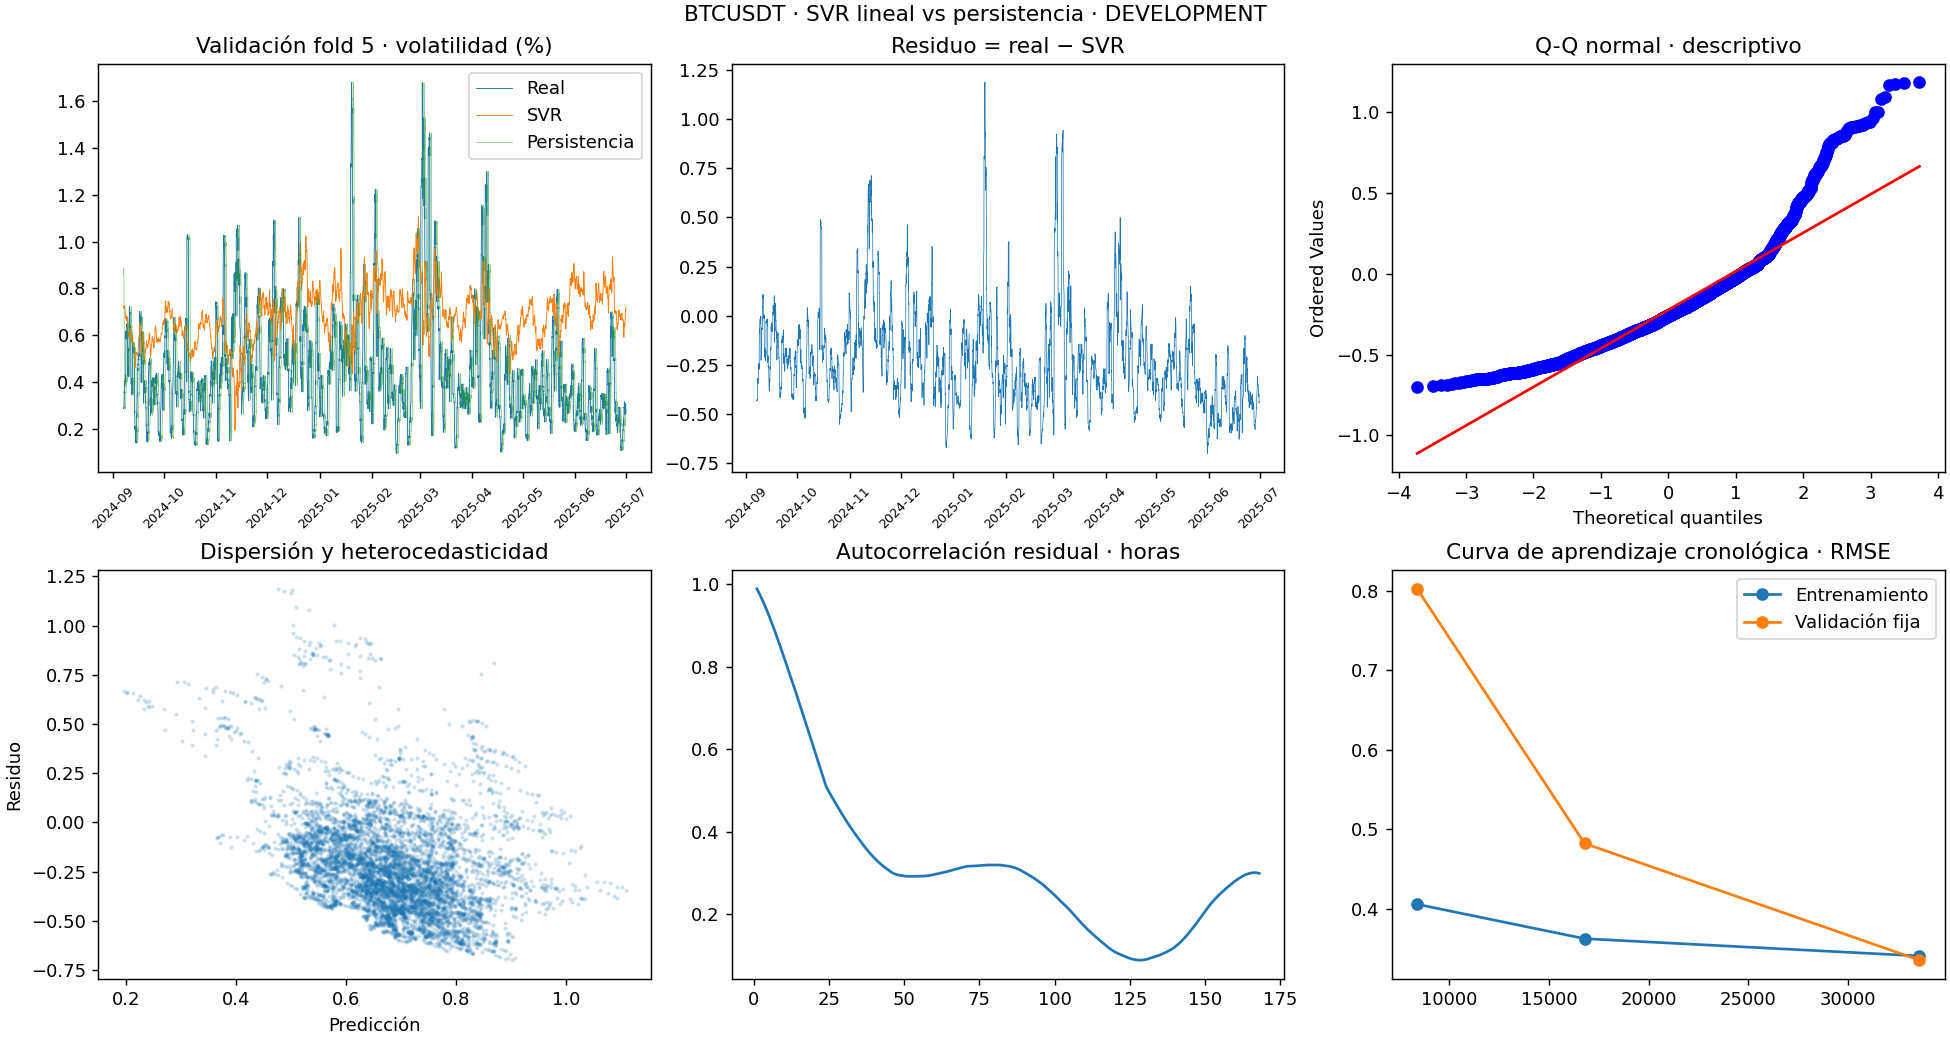

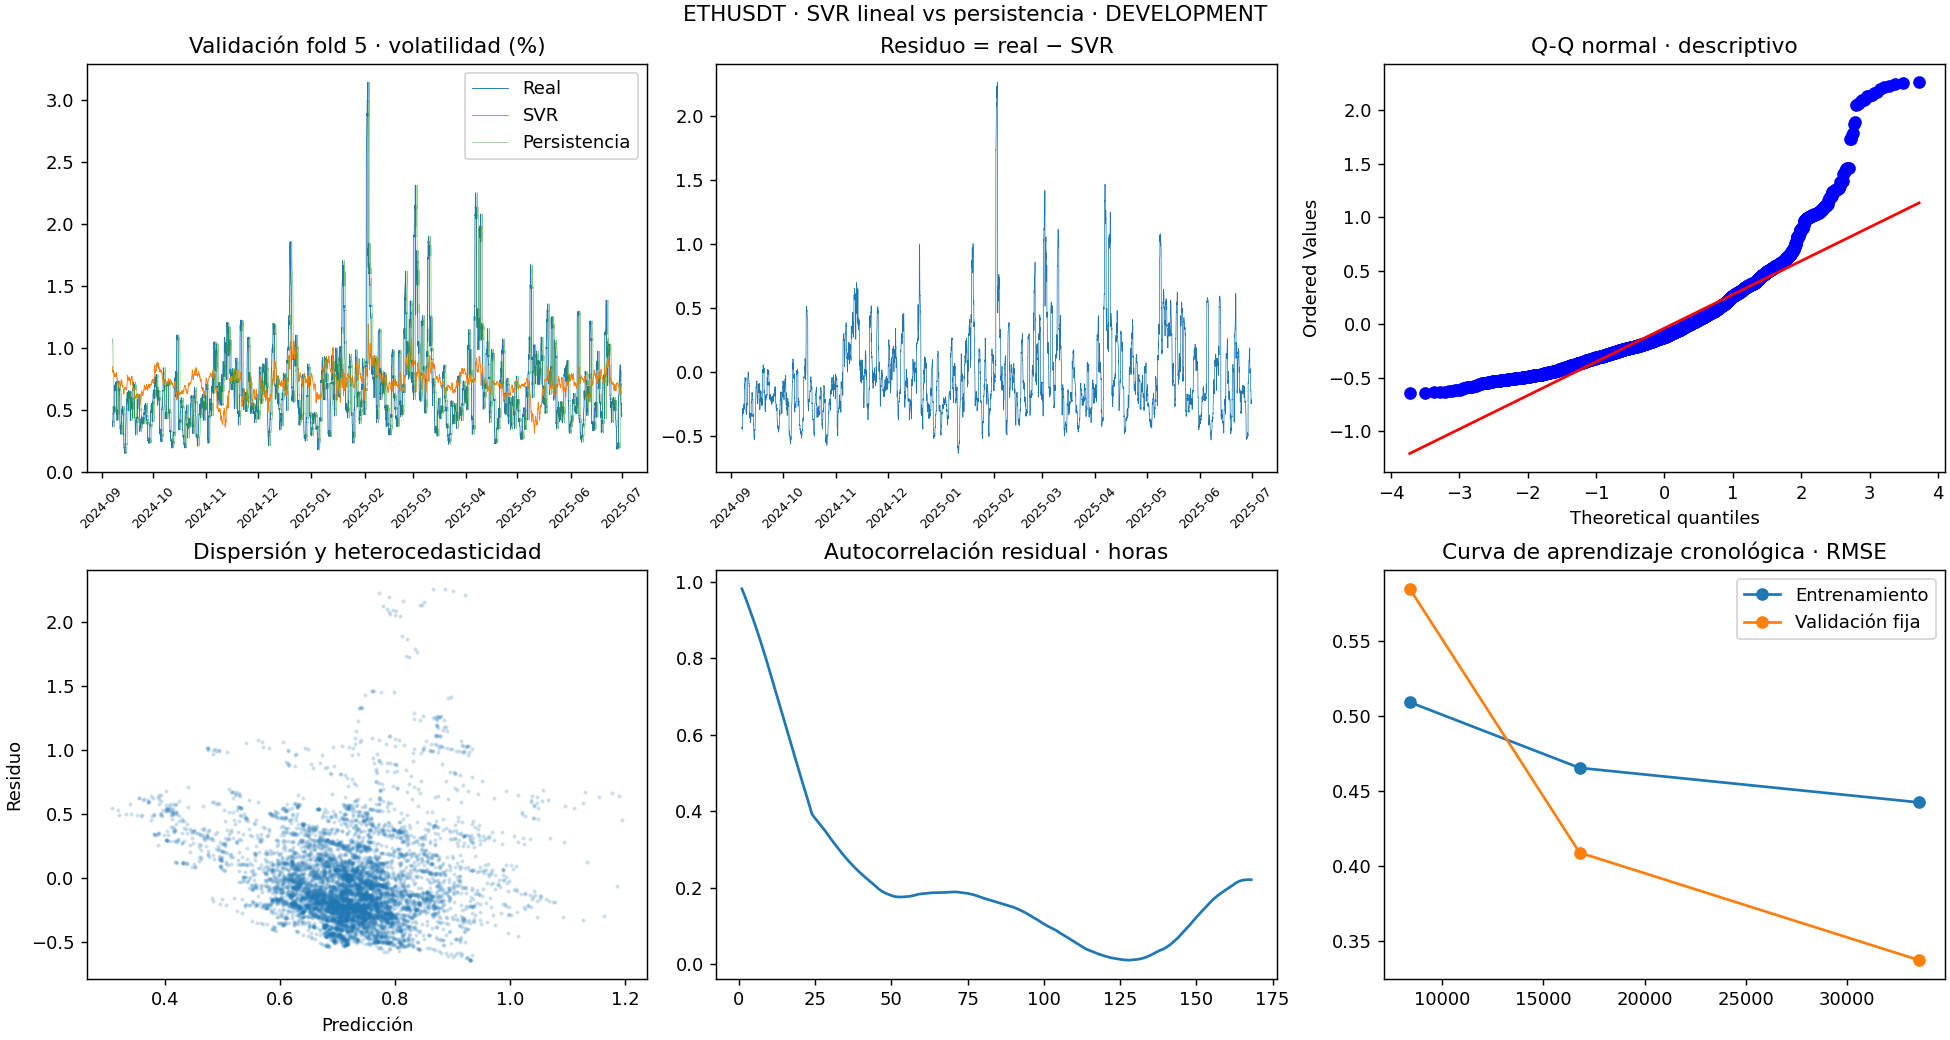

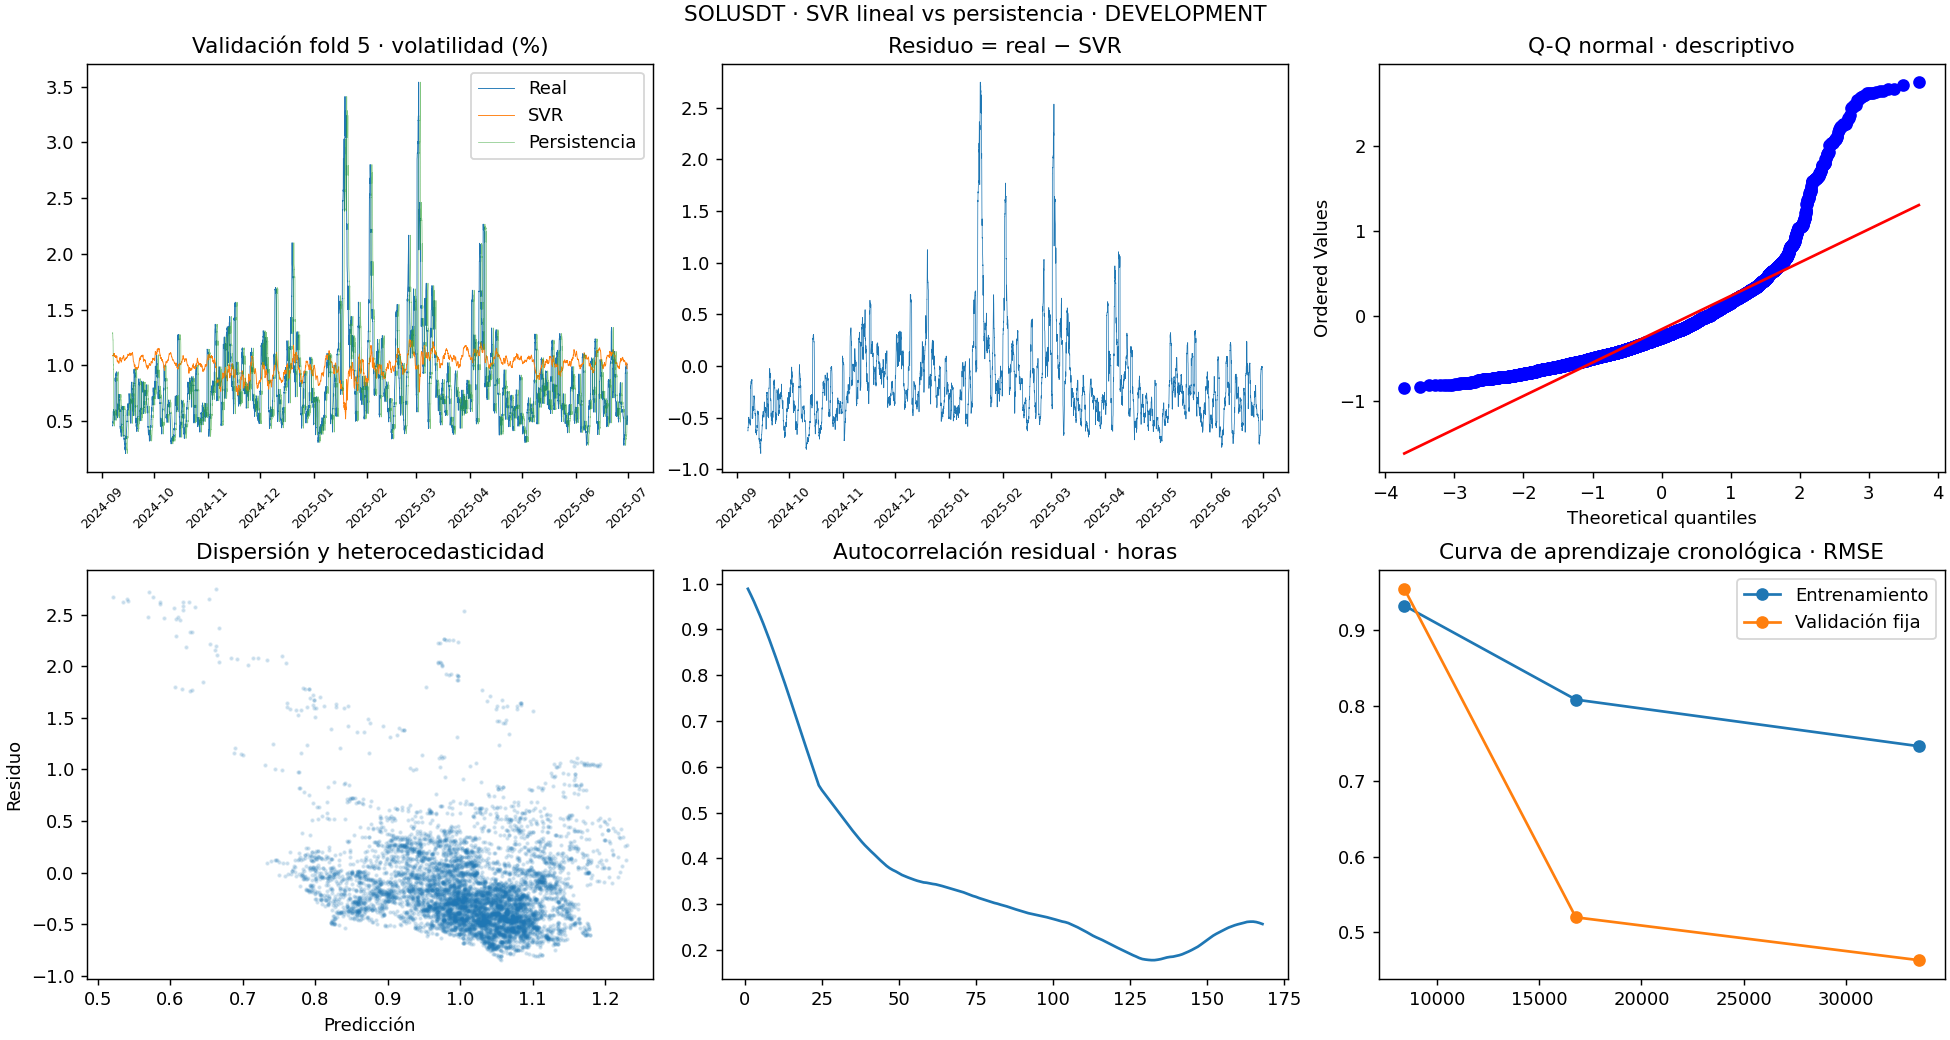

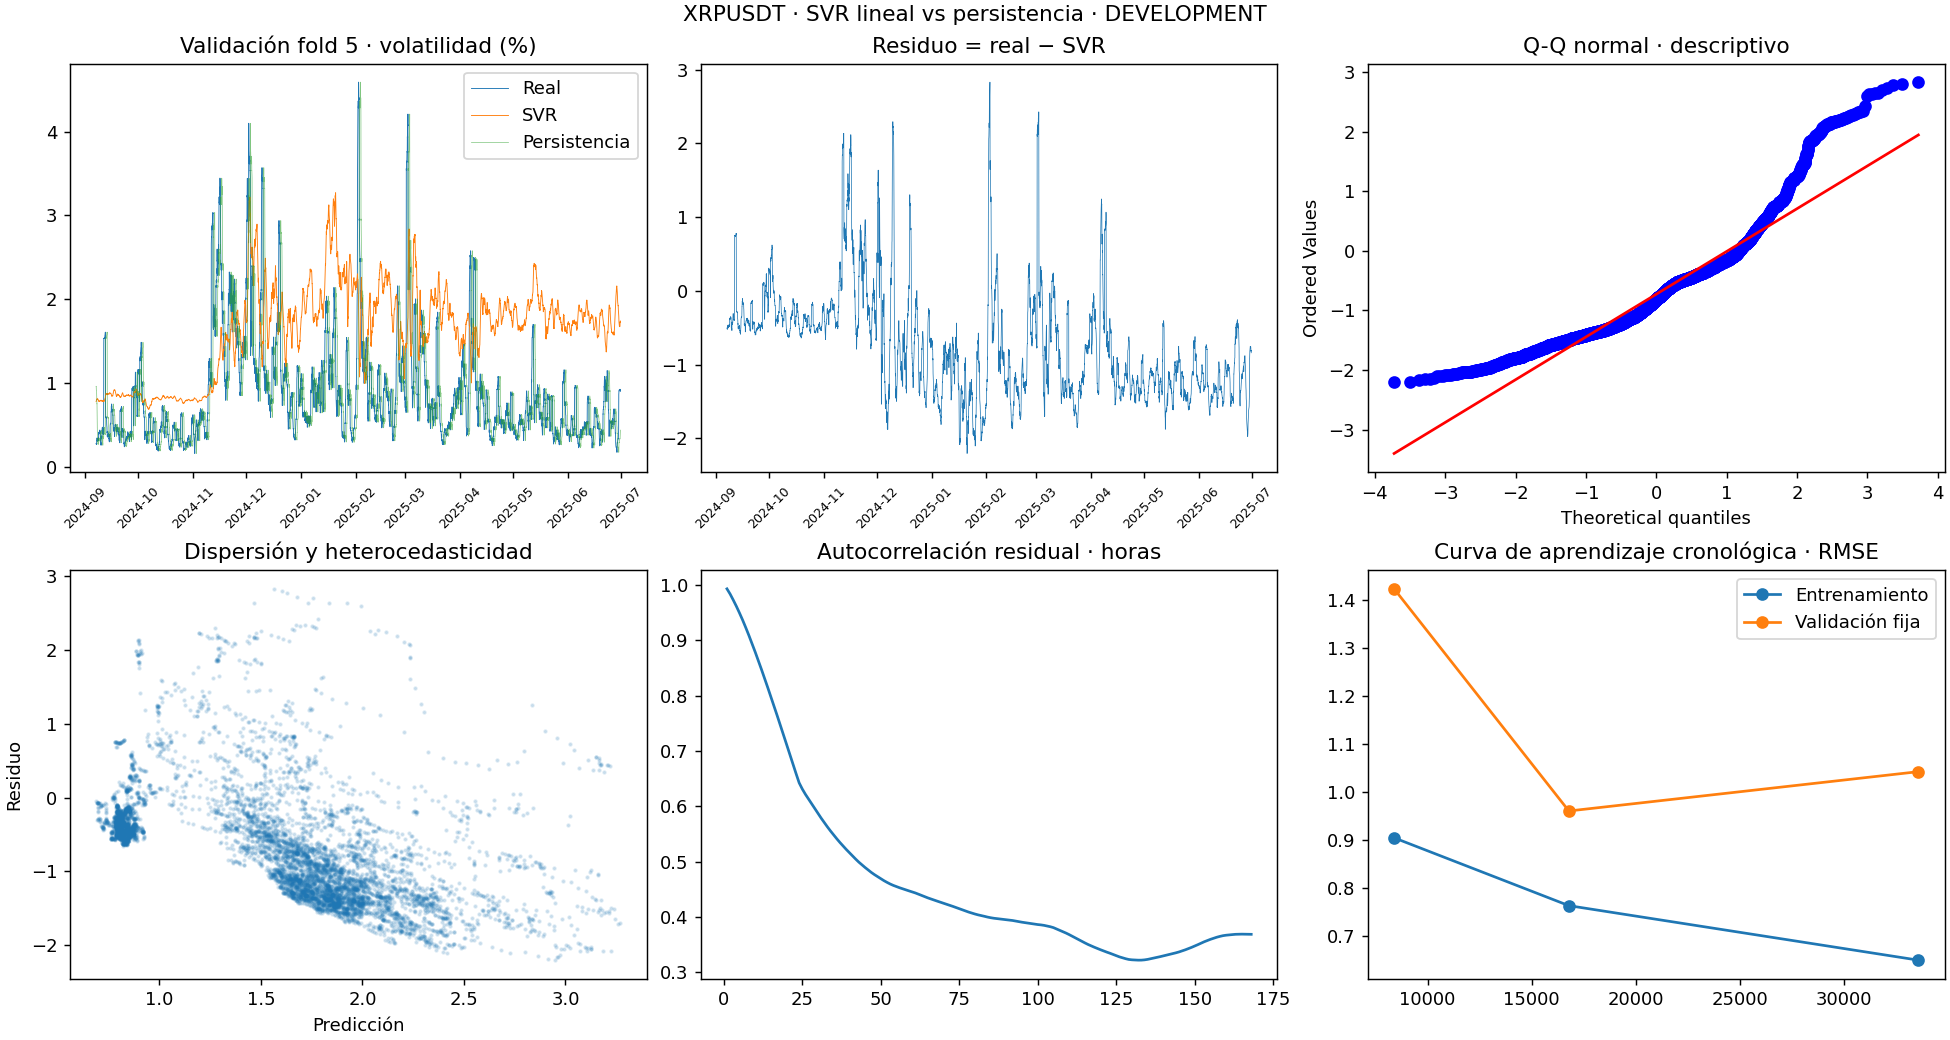

{
  "selected_C": 0.01,
  "selected_epsilon": 0.01,
  "development_sha256": "5fbbc54a12e976551b35652b72c989be8d1a120ef41cd7c6a4b50dcaf5fa87a2",
  "test_read": false,
  "eligible_common_per_asset": 40717,
  "validation_rows_per_asset": 34912,
  "seconds": 207.75167200015858,
  "sklearn": "1.7.2",
  "selection_bias": "CI conditional on selected configuration; not independent final test",
  "fits": 170
}


In [2]:
from IPython.display import display, Image
for name in ['base_selection.csv','base_metrics_by_fold.csv','base_confidence_intervals.csv','base_residual_diagnostics.csv','base_learning_curve.csv']:
    print(name)
    display(pd.read_csv(OUT/name))
for p in sorted(FIG.glob('base_*.png')):
    display(Image(filename=str(p)))
print((OUT/'base_metadata.json').read_text())